# Beauty & Personal Care Sales AnalyticsAn exploratory data analysis of a beauty & personal care sales dataset, examining channel performance, brand efficiency, customer segments, product categories, and geography to surface concrete, actionable business insights.**Dataset:** `cleaned_beauty_personal_care_dataset.csv` — product-level sales records including brand, category, channel, pricing, ratings, marketing spend, and customer behavior metrics.**Tools:** pandas, NumPy, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading & Cleaning

In [2]:
dt = pd.read_csv("cleaned_beauty_personal_care_dataset.csv")
dt

,product_id,brand,category,subcategory,ingredient_type,target_type,is_cruelty_free,launch_date,price_inr,primary_channel,...,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
0,205894,Brand_S,Skincare,Serum,Synthetic,Oily,1,2023-08-21,60.0,Nykaa,...,18,7.6,3.74,333.0,9.21,12.69,5158,281,51.5,48
1,207032,Brand_V,Bath & Body,Body Wash,Natural,Sensitive,1,2024-06-26,367.0,Amazon,...,24,3.1,3.77,211.0,0.50,18.67,6817,410,43.4,27
2,207858,Brand_E,Makeup,Blush,Hybrid,Normal,1,2022-06-09,410.0,Amazon,...,24,2.2,3.69,128.0,9.55,16.36,18138,223,46.8,16
3,202079,Brand_H,Haircare,Conditioner,Synthetic,Oily,1,2024-07-13,359.0,Instagram Shop,...,24,2.2,3.83,117.0,10.25,20.76,34519,320,-5.7,11
4,205518,Brand_I,Skincare,Sunscreen,Synthetic,Combination,0,2024-07-19,260.0,Retail/Offline,...,18,6.8,3.74,252.0,7.93,21.79,8797,124,-25.1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12085,209160,Brand_E,Bath & Body,Hand Cream,Hybrid,Dry,1,2025-03-01,339.0,Instagram Shop,...,24,0.8,4.67,27.0,5.14,22.79,23120,274,60.0,20
12086,209859,Brand_T,Skincare,Moisturizer,Hybrid,Normal,0,2023-03-27,285.0,Instagram Shop,...,18,9.2,4.11,156.0,6.68,27.26,21944,186,42.9,56
12087,211513,Brand_H,Makeup,Mascara,Hybrid,All Types,1,2025-07-15,524.0,Nykaa,...,24,4.4,4.30,176.0,6.65,26.75,35362,277,30.4,95
12088,201688,Brand_K,Haircare,Serum,Synthetic,Normal,1,2024-06-22,306.0,D2C Website,...,24,3.3,4.82,29.0,1.47,37.92,49719,202,120.0,112


In [3]:
dt.describe()

,is_cruelty_free,price_inr,units_sold_last_30d,units_sold_prev_30d,revenue_last_30d_inr,current_stock_units,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
count,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000,11788.000000,11968.000000,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000,12090.000000
mean,0.605542,497.967614,102.811332,102.735153,50506.622829,119.211001,23.745906,4.044615,3.995301,109.429479,6.166443,18.042888,30115.335153,299.586187,5.902903,60.778660
std,0.488754,449.985727,69.800052,74.409466,58779.594331,84.953200,5.226315,4.059961,0.485284,77.088762,3.571549,7.304474,21114.883134,174.461222,29.455649,90.793023
min,0.000000,60.000000,1.000000,1.000000,278.000000,1.000000,18.000000,0.000000,2.110000,1.000000,0.500000,2.000000,500.000000,13.000000,-45.500000,0.000000
25%,0.000000,271.000000,52.000000,49.000000,16524.000000,57.000000,18.000000,1.200000,3.670000,52.000000,3.490000,12.970000,14653.250000,173.000000,-12.900000,17.000000
50%,1.000000,384.000000,87.000000,84.000000,32488.000000,101.000000,24.000000,2.800000,4.000000,92.000000,6.040000,18.020000,25444.000000,263.000000,0.000000,34.000000
75%,1.000000,531.000000,137.000000,137.000000,61146.000000,159.000000,24.000000,5.700000,4.330000,148.000000,8.570000,23.067500,40145.750000,385.000000,17.100000,69.000000
max,1.000000,13162.614302,625.000000,793.000000,871089.000000,773.000000,36.000000,30.000000,5.000000,619.000000,20.780000,43.740000,183228.000000,1654.000000,612.500000,999.000000


In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12090 entries, 0 to 12089
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                12090 non-null  object 
 1   brand                     12090 non-null  object 
 2   category                  12090 non-null  object 
 3   subcategory               12090 non-null  object 
 4   ingredient_type           12090 non-null  object 
 5   target_type               11848 non-null  object 
 6   is_cruelty_free           12090 non-null  int64  
 7   launch_date               12090 non-null  object 
 8   price_inr                 12090 non-null  float64
 9   primary_channel           12090 non-null  object 
 10  top_customer_city         12090 non-null  object 
 11  units_sold_last_30d       12090 non-null  int64  
 12  units_sold_prev_30d       12090 non-null  int64  
 13  revenue_last_30d_inr      12090 non-null  float64
 14  curren

In [6]:
dt.isnull().sum()

product_id                    0
brand                         0
category                      0
subcategory                   0
ingredient_type               0
target_type                 242
is_cruelty_free               0
launch_date                   0
price_inr                     0
primary_channel               0
top_customer_city             0
units_sold_last_30d           0
units_sold_prev_30d           0
revenue_last_30d_inr          0
current_stock_units           0
shelf_life_months             0
months_since_last_batch       0
avg_rating                  302
num_reviews                 122
return_rate_pct               0
repeat_purchase_rate_pct      0
marketing_spend_inr_30d       0
social_mentions_30d           0
sell_through_change_pct       0
stockout_risk_days            0
dtype: int64

In [9]:
dt["num_reviews"].fillna(dt["num_reviews"].mean(),inplace=True)

C:\Users\nikit\AppData\Local\Temp\ipykernel_10948\3244004804.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dt["num_reviews"].fillna(dt["num_reviews"].mean(),inplace=True)


In [10]:
dt["product_id"] = (
    dt["product_id"]
    .str.replace("SKU", "", regex=False)
    .astype(int)
)

In [11]:
dt.duplicated().sum()

np.int64(89)

In [12]:
dt.drop_duplicates()

,product_id,brand,category,subcategory,ingredient_type,target_type,is_cruelty_free,launch_date,price_inr,primary_channel,...,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
0,205894,Brand_S,Skincare,Serum,Synthetic,Oily,1,2023-08-21,60.0,Nykaa,...,18,7.6,3.74,333.0,9.21,12.69,5158,281,51.5,48
1,207032,Brand_V,Bath & Body,Body Wash,Natural,Sensitive,1,2024-06-26,367.0,Amazon,...,24,3.1,3.77,211.0,0.50,18.67,6817,410,43.4,27
2,207858,Brand_E,Makeup,Blush,Hybrid,Normal,1,2022-06-09,410.0,Amazon,...,24,2.2,3.69,128.0,9.55,16.36,18138,223,46.8,16
3,202079,Brand_H,Haircare,Conditioner,Synthetic,Oily,1,2024-07-13,359.0,Instagram Shop,...,24,2.2,3.83,117.0,10.25,20.76,34519,320,-5.7,11
4,205518,Brand_I,Skincare,Sunscreen,Synthetic,Combination,0,2024-07-19,260.0,Retail/Offline,...,18,6.8,3.74,252.0,7.93,21.79,8797,124,-25.1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12085,209160,Brand_E,Bath & Body,Hand Cream,Hybrid,Dry,1,2025-03-01,339.0,Instagram Shop,...,24,0.8,4.67,27.0,5.14,22.79,23120,274,60.0,20
12086,209859,Brand_T,Skincare,Moisturizer,Hybrid,Normal,0,2023-03-27,285.0,Instagram Shop,...,18,9.2,4.11,156.0,6.68,27.26,21944,186,42.9,56
12087,211513,Brand_H,Makeup,Mascara,Hybrid,All Types,1,2025-07-15,524.0,Nykaa,...,24,4.4,4.30,176.0,6.65,26.75,35362,277,30.4,95
12088,201688,Brand_K,Haircare,Serum,Synthetic,Normal,1,2024-06-22,306.0,D2C Website,...,24,3.3,4.82,29.0,1.47,37.92,49719,202,120.0,112


## Exploratory Overview

In [24]:
dt["brand"].value_counts()

brand
Brand_F    603
Brand_L    581
Brand_O    580
Brand_E    579
Brand_D    575
Brand_Q    564
Brand_K    558
Brand_S    555
Brand_V    554
Brand_N    552
Brand_A    550
Brand_G    545
Brand_I    544
Brand_P    540
Brand_U    538
Brand_T    537
Brand_M    533
Brand_B    531
Brand_H    528
Brand_C    523
Brand_J    510
Brand_R    510
Name: count, dtype: int64

In [25]:
dt["category"].value_counts()

category
Skincare       3406
Makeup         2878
Haircare       2865
Bath & Body    1494
Fragrance      1447
Name: count, dtype: int64

In [29]:
dt["subcategory"].value_counts()

subcategory
Serum              1047
Cleanser            592
Face Mask           578
Sunscreen           570
Toner               565
Moisturizer         545
Concealer           529
Styling Cream       506
Conditioner         499
Eyeliner            497
Mascara             496
Hair Oil            475
Lipstick            459
Blush               457
Shampoo             448
Hair Mask           446
Foundation          440
Body Lotion         383
Body Scrub          381
Hand Cream          375
Eau de Parfum       373
Attar               372
Eau de Toilette     361
Body Wash           355
Body Mist           341
Name: count, dtype: int64

In [30]:
dt["ingredient_type"].value_counts()

ingredient_type
Natural      4235
Synthetic    3624
Ayurvedic    2380
Hybrid       1851
Name: count, dtype: int64

In [35]:
dt["target_type"].value_counts()

target_type
Combination    2253
All Types      2001
Oily           1993
Dry            1979
Normal         1963
Sensitive      1901
Name: count, dtype: int64

In [36]:
dt["primary_channel"].value_counts()

primary_channel
Instagram Shop    2049
D2C Website       2042
Retail/Offline    2033
Quick Commerce    2029
Amazon            1993
Nykaa             1944
Name: count, dtype: int64

In [5]:
pd.set_option('display.max_columns',None)
dt

,product_id,brand,category,subcategory,ingredient_type,target_type,is_cruelty_free,launch_date,price_inr,primary_channel,top_customer_city,units_sold_last_30d,units_sold_prev_30d,revenue_last_30d_inr,current_stock_units,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
0,205894,Brand_S,Skincare,Serum,Synthetic,Oily,1,2023-08-21,60.0,Nykaa,Chennai,50,33,3000.0,80,18,7.6,3.74,333.0,9.21,12.69,5158,281,51.5,48
1,207032,Brand_V,Bath & Body,Body Wash,Natural,Sensitive,1,2024-06-26,367.0,Amazon,Hyderabad,109,76,40003.0,97,24,3.1,3.77,211.0,0.50,18.67,6817,410,43.4,27
2,207858,Brand_E,Makeup,Blush,Hybrid,Normal,1,2022-06-09,410.0,Amazon,Delhi,232,158,95120.0,123,24,2.2,3.69,128.0,9.55,16.36,18138,223,46.8,16
3,202079,Brand_H,Haircare,Conditioner,Synthetic,Oily,1,2024-07-13,359.0,Instagram Shop,Kolkata,164,174,58876.0,62,24,2.2,3.83,117.0,10.25,20.76,34519,320,-5.7,11
4,205518,Brand_I,Skincare,Sunscreen,Synthetic,Combination,0,2024-07-19,260.0,Retail/Offline,Ahmedabad,218,291,56680.0,38,18,6.8,3.74,252.0,7.93,21.79,8797,124,-25.1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12085,209160,Brand_E,Bath & Body,Hand Cream,Hybrid,Dry,1,2025-03-01,339.0,Instagram Shop,Pune,80,50,27120.0,53,24,0.8,4.67,27.0,5.14,22.79,23120,274,60.0,20
12086,209859,Brand_T,Skincare,Moisturizer,Hybrid,Normal,0,2023-03-27,285.0,Instagram Shop,Bengaluru,30,21,8550.0,57,18,9.2,4.11,156.0,6.68,27.26,21944,186,42.9,56
12087,211513,Brand_H,Makeup,Mascara,Hybrid,All Types,1,2025-07-15,524.0,Nykaa,Bengaluru,73,56,38252.0,231,24,4.4,4.30,176.0,6.65,26.75,35362,277,30.4,95
12088,201688,Brand_K,Haircare,Serum,Synthetic,Normal,1,2024-06-22,306.0,D2C Website,Hyderabad,11,5,3366.0,42,24,3.3,4.82,29.0,1.47,37.92,49719,202,120.0,112


In [38]:
dt["top_customer_city"].value_counts()

top_customer_city
Chennai      1264
Mumbai       1251
Pune         1232
Bengaluru    1214
Kolkata      1211
Ahmedabad    1197
Lucknow      1195
Jaipur       1195
Hyderabad    1168
Delhi        1163
Name: count, dtype: int64

## Channel & Sales Performance

In [6]:
d = dt.groupby("primary_channel")["units_sold_prev_30d"].sum().sort_values(ascending=False)
pd.set_option('display.max_row',None)
d

primary_channel
Retail/Offline    210257
Instagram Shop    210078
Quick Commerce    208850
D2C Website       208201
Amazon            204300
Nykaa             200382
Name: units_sold_prev_30d, dtype: int64

In [43]:
dt.groupby("primary_channel")["units_sold_last_30d"].sum().sort_values(ascending=False)

primary_channel
Instagram Shop    211594
Retail/Offline    210362
D2C Website       209069
Amazon            206500
Quick Commerce    206331
Nykaa             199133
Name: units_sold_last_30d, dtype: int64

In [42]:
dt.groupby("primary_channel")["revenue_last_30d_inr"].sum().sort_values(ascending=False)

primary_channel
Instagram Shop    104518828.0
Retail/Offline    103879415.0
Quick Commerce    102688403.0
D2C Website       102467118.0
Amazon            101070508.0
Nykaa              96000798.0
Name: revenue_last_30d_inr, dtype: float64

In [13]:
df=dt.groupby("brand")[["marketing_spend_inr_30d","revenue_last_30d_inr"]].sum()
df

,marketing_spend_inr_30d,revenue_last_30d_inr
brand,,
Brand_A,16801812,27972174.0
Brand_B,15179687,27274918.0
Brand_C,15298238,27737265.0
Brand_D,17236431,28282212.0
Brand_E,17653343,31362064.0
Brand_F,18547997,28285389.0
Brand_G,16610910,29435751.0
Brand_H,15148493,24496189.0
Brand_I,16286977,25914673.0


In [72]:
dt.to_csv("cleaned_beauty_personal_care_dataset.csv", index=False)

In [23]:
dt.groupby("brand")[["category","primary_channel","revenue_last_30d_inr"]].value_counts()

brand    category     primary_channel  revenue_last_30d_inr
Brand_A  Haircare     D2C Website      96316.0                 2
                      Nykaa            14596.0                 2
         Bath & Body  Amazon           1296.0                  1
                                       2940.0                  1
                                       3420.0                  1
                                       9504.0                  1
                                       9828.0                  1
                                       10350.0                 1
                                       13530.0                 1
                                       13818.0                 1
                                       15045.0                 1
                                       17584.0                 1
                      D2C Website      2256.0                  1
                                       12679.0                 1
                              

In [37]:
dt.groupby("brand")[["top_customer_city","revenue_last_30d_inr"]].value_counts().sort_values(ascending=False)

brand    top_customer_city  revenue_last_30d_inr
Brand_H  Lucknow            15708.0                 2
Brand_A  Bengaluru          14596.0                 2
Brand_H  Lucknow            54981.0                 2
         Pune               13552.0                 2
                            62062.0                 2
Brand_J  Chennai            84084.0                 2
Brand_D  Kolkata            17248.0                 2
         Mumbai             20661.0                 2
         Pune               104082.0                2
Brand_J  Hyderabad          73315.0                 2
         Kolkata            17900.0                 2
Brand_K  Bengaluru          20590.0                 2
         Lucknow            6532.0                  2
         Mumbai             2760.0                  2
Brand_F  Delhi              25424.0                 2
                            53360.0                 2
         Jaipur             23865.0                 2
         Lucknow            62856

In [38]:
dt.groupby("brand")["top_customer_city"].value_counts()

brand    top_customer_city
Brand_A  Pune                 68
         Lucknow              60
         Bengaluru            58
         Jaipur               58
         Kolkata              57
         Ahmedabad            55
         Mumbai               51
         Hyderabad            49
         Chennai              47
         Delhi                47
Brand_B  Pune                 66
         Lucknow              62
         Ahmedabad            61
         Chennai              59
         Mumbai               51
         Hyderabad            50
         Delhi                48
         Bengaluru            47
         Kolkata              45
         Jaipur               42
Brand_C  Delhi                60
         Mumbai               57
         Hyderabad            54
         Ahmedabad            53
         Lucknow              53
         Jaipur               52
         Chennai              49
         Pune                 49
         Bengaluru            48
         Kolkata

In [50]:
dt.groupby("brand")["avg_rating"].value_counts().sort_values(ascending=False)

brand    avg_rating
Brand_C  3.995301      22
Brand_O  3.995301      20
Brand_T  3.995301      19
Brand_I  5.000000      18
Brand_B  3.995301      18
Brand_U  3.995301      18
         5.000000      17
Brand_A  3.995301      16
Brand_E  3.995301      16
Brand_P  5.000000      15
Brand_N  5.000000      15
Brand_V  3.995301      15
Brand_H  5.000000      15
Brand_E  5.000000      15
Brand_M  3.995301      14
Brand_H  3.995301      14
Brand_T  5.000000      14
Brand_M  5.000000      13
Brand_K  3.995301      13
Brand_R  3.995301      13
Brand_D  3.995301      13
Brand_Q  4.000000      13
         3.995301      12
Brand_G  3.995301      12
Brand_B  5.000000      12
Brand_D  5.000000      12
Brand_A  5.000000      12
Brand_F  3.850000      12
         5.000000      12
Brand_T  3.950000      12
Brand_N  4.030000      11
Brand_O  4.220000      11
Brand_L  5.000000      11
Brand_R  5.000000      11
Brand_Q  3.660000      11
         3.970000      11
Brand_S  3.995301      11
Brand_F  3.860000 

In [57]:
dt.groupby("primary_channel")["repeat_purchase_rate_pct"].sum().sort_values(ascending=False)

primary_channel
Instagram Shop    37091.96
D2C Website       37059.50
Quick Commerce    36664.48
Retail/Offline    36541.10
Nykaa             35434.42
Amazon            35347.06
Name: repeat_purchase_rate_pct, dtype: float64

In [65]:
dt.groupby("primary_channel")["repeat_purchase_rate_pct"].max().sort_values(ascending=False)

primary_channel
Instagram Shop    43.74
Nykaa             43.65
D2C Website       42.66
Amazon            41.60
Quick Commerce    41.10
Retail/Offline    39.69
Name: repeat_purchase_rate_pct, dtype: float64

In [10]:
dt.head(3)

,product_id,brand,category,subcategory,ingredient_type,target_type,is_cruelty_free,launch_date,price_inr,primary_channel,top_customer_city,units_sold_last_30d,units_sold_prev_30d,revenue_last_30d_inr,current_stock_units,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
0,205894,Brand_S,Skincare,Serum,Synthetic,Oily,1,2023-08-21,60.0,Nykaa,Chennai,50,33,3000.0,80,18,7.6,3.74,333.0,9.21,12.69,5158,281,51.5,48
1,207032,Brand_V,Bath & Body,Body Wash,Natural,Sensitive,1,2024-06-26,367.0,Amazon,Hyderabad,109,76,40003.0,97,24,3.1,3.77,211.0,0.50,18.67,6817,410,43.4,27
2,207858,Brand_E,Makeup,Blush,Hybrid,Normal,1,2022-06-09,410.0,Amazon,Delhi,232,158,95120.0,123,24,2.2,3.69,128.0,9.55,16.36,18138,223,46.8,16


## Customer Analysis

In [8]:
dt.groupby("target_type")["revenue_last_30d_inr"].sum()

target_type
All Types      100141100.0
Combination    117217924.0
Dry             98368084.0
Normal          99360815.0
Oily           103769128.0
Sensitive       91768019.0
Name: revenue_last_30d_inr, dtype: float64

In [11]:
dt.groupby("target_type")["ingredient_type"].value_counts().sort_values(ascending=False)

target_type  ingredient_type
Combination  Natural            813
Oily         Natural            719
Dry          Natural            712
All Types    Natural            685
Combination  Synthetic          677
Sensitive    Natural            653
Normal       Natural            653
All Types    Synthetic          604
Normal       Synthetic          592
Oily         Synthetic          592
Dry          Synthetic          585
Sensitive    Synthetic          574
Combination  Ayurvedic          446
Normal       Ayurvedic          413
All Types    Ayurvedic          389
Oily         Ayurvedic          386
Dry          Ayurvedic          380
Sensitive    Ayurvedic          366
All Types    Hybrid             323
Combination  Hybrid             317
Sensitive    Hybrid             308
Normal       Hybrid             305
Dry          Hybrid             302
Oily         Hybrid             296
Name: count, dtype: int64

In [15]:
dt.groupby("target_type")["units_sold_last_30d"].sum()

target_type
All Types      205629
Combination    233649
Dry            198131
Normal         205087
Oily           205146
Sensitive      195347
Name: units_sold_last_30d, dtype: int64

## Product Analysis

In [20]:
dt.groupby("subcategory")["units_sold_last_30d"].sum().sort_values(ascending=False)

subcategory
Serum              109041
Cleanser            65930
Sunscreen           65430
Toner               65240
Moisturizer         64734
Face Mask           64013
Styling Cream       53325
Concealer           52869
Conditioner         48169
Hair Oil            47882
Blush               47628
Mascara             47372
Eyeliner            46880
Lipstick            45389
Foundation          45353
Shampoo             44690
Hair Mask           41008
Hand Cream          38245
Body Lotion         37266
Eau de Parfum       36776
Body Scrub          36125
Attar               36063
Body Wash           35247
Eau de Toilette     34489
Body Mist           33825
Name: units_sold_last_30d, dtype: int64

In [22]:
dt.groupby("subcategory")["revenue_last_30d_inr"].sum().sort_values(ascending=False)

subcategory
Eau de Parfum      52255403.0
Attar              51091639.0
Eau de Toilette    49146646.0
Body Mist          46307169.0
Serum              42684873.0
Sunscreen          29431167.0
Toner              29238776.0
Cleanser           29235078.0
Face Mask          29179877.0
Moisturizer        28878585.0
Concealer          20629350.0
Blush              18413710.0
Mascara            17891559.0
Eyeliner           17188988.0
Lipstick           17050740.0
Foundation         17028436.0
Styling Cream      17003274.0
Conditioner        15710904.0
Hair Oil           14970843.0
Shampoo            14688326.0
Hair Mask          13158565.0
Hand Cream         10527443.0
Body Scrub          9779163.0
Body Wash           9602885.0
Body Lotion         9531671.0
Name: revenue_last_30d_inr, dtype: float64

In [37]:
dt.groupby("subcategory")[["price_inr","avg_rating"]].value_counts().sort_values(ascending=False)

subcategory      price_inr     avg_rating
Eyeliner         60.000000     3.995301      3
Attar            1625.000000   3.950000      2
Face Mask        521.000000    4.120000      2
Eau de Parfum    1108.000000   3.850000      2
                 1724.000000   4.000000      2
Face Mask        549.000000    4.300000      2
Eau de Toilette  314.000000    3.590000      2
                 473.000000    3.990000      2
                 711.000000    4.160000      2
                 1180.000000   3.760000      2
Face Mask        872.000000    4.090000      2
Body Wash        169.000000    4.520000      2
                 237.000000    3.770000      2
                 272.000000    3.810000      2
                 291.000000    3.990000      2
Body Mist        60.000000     3.970000      2
Body Wash        394.000000    3.740000      2
Foundation       239.000000    3.330000      2
                 293.000000    3.420000      2
                 354.000000    3.860000      2
Cleanser         2

In [35]:
dt.sort_values("avg_rating", ascending=False)[
    ["subcategory", "avg_rating", "units_sold_last_30d"]
]

,subcategory,avg_rating,units_sold_last_30d
675,Eau de Toilette,5.000000,90
695,Shampoo,5.000000,47
11033,Serum,5.000000,42
11025,Sunscreen,5.000000,10
11009,Concealer,5.000000,67
722,Concealer,5.000000,38
717,Toner,5.000000,243
10766,Blush,5.000000,89
10743,Hair Mask,5.000000,69
4554,Cleanser,5.000000,155


In [6]:
dt

,product_id,brand,category,subcategory,ingredient_type,target_type,is_cruelty_free,launch_date,price_inr,primary_channel,top_customer_city,units_sold_last_30d,units_sold_prev_30d,revenue_last_30d_inr,current_stock_units,shelf_life_months,months_since_last_batch,avg_rating,num_reviews,return_rate_pct,repeat_purchase_rate_pct,marketing_spend_inr_30d,social_mentions_30d,sell_through_change_pct,stockout_risk_days
0,205894,Brand_S,Skincare,Serum,Synthetic,Oily,1,2023-08-21,60.0,Nykaa,Chennai,50,33,3000.0,80,18,7.6,3.74,333.0,9.21,12.69,5158,281,51.5,48
1,207032,Brand_V,Bath & Body,Body Wash,Natural,Sensitive,1,2024-06-26,367.0,Amazon,Hyderabad,109,76,40003.0,97,24,3.1,3.77,211.0,0.50,18.67,6817,410,43.4,27
2,207858,Brand_E,Makeup,Blush,Hybrid,Normal,1,2022-06-09,410.0,Amazon,Delhi,232,158,95120.0,123,24,2.2,3.69,128.0,9.55,16.36,18138,223,46.8,16
3,202079,Brand_H,Haircare,Conditioner,Synthetic,Oily,1,2024-07-13,359.0,Instagram Shop,Kolkata,164,174,58876.0,62,24,2.2,3.83,117.0,10.25,20.76,34519,320,-5.7,11
4,205518,Brand_I,Skincare,Sunscreen,Synthetic,Combination,0,2024-07-19,260.0,Retail/Offline,Ahmedabad,218,291,56680.0,38,18,6.8,3.74,252.0,7.93,21.79,8797,124,-25.1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12085,209160,Brand_E,Bath & Body,Hand Cream,Hybrid,Dry,1,2025-03-01,339.0,Instagram Shop,Pune,80,50,27120.0,53,24,0.8,4.67,27.0,5.14,22.79,23120,274,60.0,20
12086,209859,Brand_T,Skincare,Moisturizer,Hybrid,Normal,0,2023-03-27,285.0,Instagram Shop,Bengaluru,30,21,8550.0,57,18,9.2,4.11,156.0,6.68,27.26,21944,186,42.9,56
12087,211513,Brand_H,Makeup,Mascara,Hybrid,All Types,1,2025-07-15,524.0,Nykaa,Bengaluru,73,56,38252.0,231,24,4.4,4.30,176.0,6.65,26.75,35362,277,30.4,95
12088,201688,Brand_K,Haircare,Serum,Synthetic,Normal,1,2024-06-22,306.0,D2C Website,Hyderabad,11,5,3366.0,42,24,3.3,4.82,29.0,1.47,37.92,49719,202,120.0,112


## Marketing Analysis

In [4]:
dt["primary_channel"].value_counts()

primary_channel
Instagram Shop    2049
D2C Website       2042
Retail/Offline    2033
Quick Commerce    2029
Amazon            1993
Nykaa             1944
Name: count, dtype: int64

In [11]:
dt.groupby("primary_channel")["repeat_purchase_rate_pct"].max().sort_values(ascending=False)

primary_channel
Instagram Shop    43.74
Nykaa             43.65
D2C Website       42.66
Amazon            41.60
Quick Commerce    41.10
Retail/Offline    39.69
Name: repeat_purchase_rate_pct, dtype: float64

In [71]:
dt.groupby("primary_channel")["return_rate_pct"].max().sort_values(ascending=False)

primary_channel
Retail/Offline    20.78
Amazon            19.80
Quick Commerce    19.79
D2C Website       19.48
Nykaa             18.83
Instagram Shop    17.98
Name: return_rate_pct, dtype: float64

## Geography Analysis

In [13]:
dt.groupby("top_customer_city")["revenue_last_30d_inr"].sum().sort_values(ascending=False)

top_customer_city
Chennai      66269047.0
Bengaluru    63193779.0
Ahmedabad    63027512.0
Mumbai       62422627.0
Pune         62315355.0
Jaipur       60295344.0
Kolkata      59764463.0
Hyderabad    58706909.0
Delhi        58315700.0
Lucknow      56314334.0
Name: revenue_last_30d_inr, dtype: float64

## Key Insights

In [ ]:
1.Instagram Shop leads on revenue, repeat purchase rate (43.7%), and lowest return rate (18.0%) — best-performing channel overall.
2.Retail/Offline has the highest return rate (20.8%) and is losing share to Instagram Shop.
3.Nykaa has the lowest revenue of all six channels despite being a beauty-dedicated platform.
4.Marketing efficiency varies sharply by brand: Brand_L (₹1.89 revenue/₹1 spend) and Brand_C (₹1.81) are most efficient; Brand_F (₹1.53) and Brand_R (₹1.54) are least — Brand_F has the highest budget but weak returns on it.
5.Revenue is fairly even across cities (₹5.63cr–₹6.63cr).
6.Chennai leads; Delhi and Hyderabad rank near the bottom, defying typical metro = highest revenue assumptions.
7.Combination skin type drives the most revenue (₹11.7cr) and volume (233K units); Sensitive is lowest on both.
8.Natural ingredients are the most popular formulation type across every skin type, followed by Synthetic, then Ayurvedic, then Hybrid (consistently smallest).
9.Serum sells the most units (109K) but ranks only 5th in revenue.
10.Fragrance subcategories (Eau de Parfum, Attar, Eau de Toilette, Body Mist) take the top 4 revenue spots despite mid-pack unit sales — high price point/margin category.
11.Body care items (Body Wash, Body Lotion, Body Scrub, Hand Cream) are the bottom 4 subcategories by revenue.

## Recommendations

In [ ]:
1.Shift incremental marketing spend toward Instagram Shop and away from Retail/Offline, given the loyalty + low-return combination.
2.Audit Brand_F and Brand_Rs marketing spend — high budget isnt converting to proportional revenue; find out what Brand_L and Brand_C are doing differently.
3.Investigate the Nykaa underperformance — its a beauty-native platform, so low revenue there is a flag, not just noise.
4.Treat fragrance as a margin/revenue priority category, not just a volume one — Serum drives foot traffic/units, but fragrance drives the P&L.
5.Dont assume Tier-1 cities are the growth priority — Chennai, Ahmedabad, and Pune outperforming Delhi/Hyderabad is worth a deeper regional dig before allocating expansion budget.

## Visualizations

<Axes: xlabel='category'>

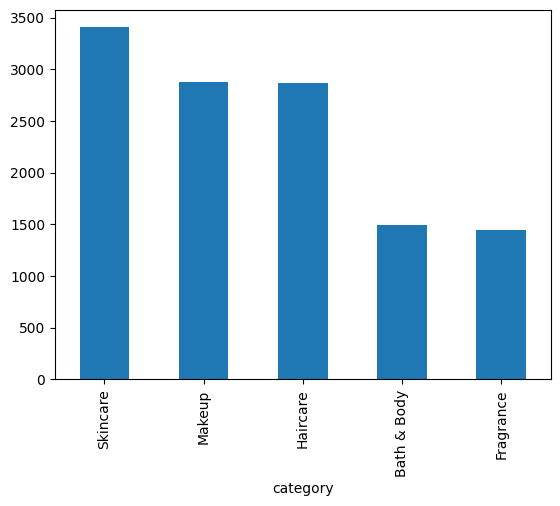

In [6]:
dt["category"].value_counts().plot(kind="bar")

<Axes: xlabel='subcategory'>

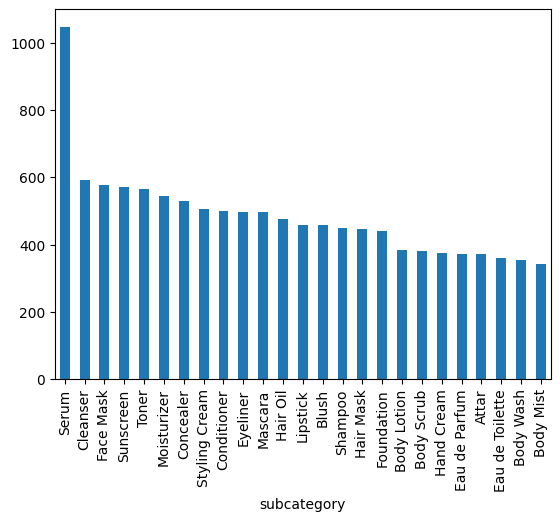

In [7]:
dt["subcategory"].value_counts().plot(kind="bar")

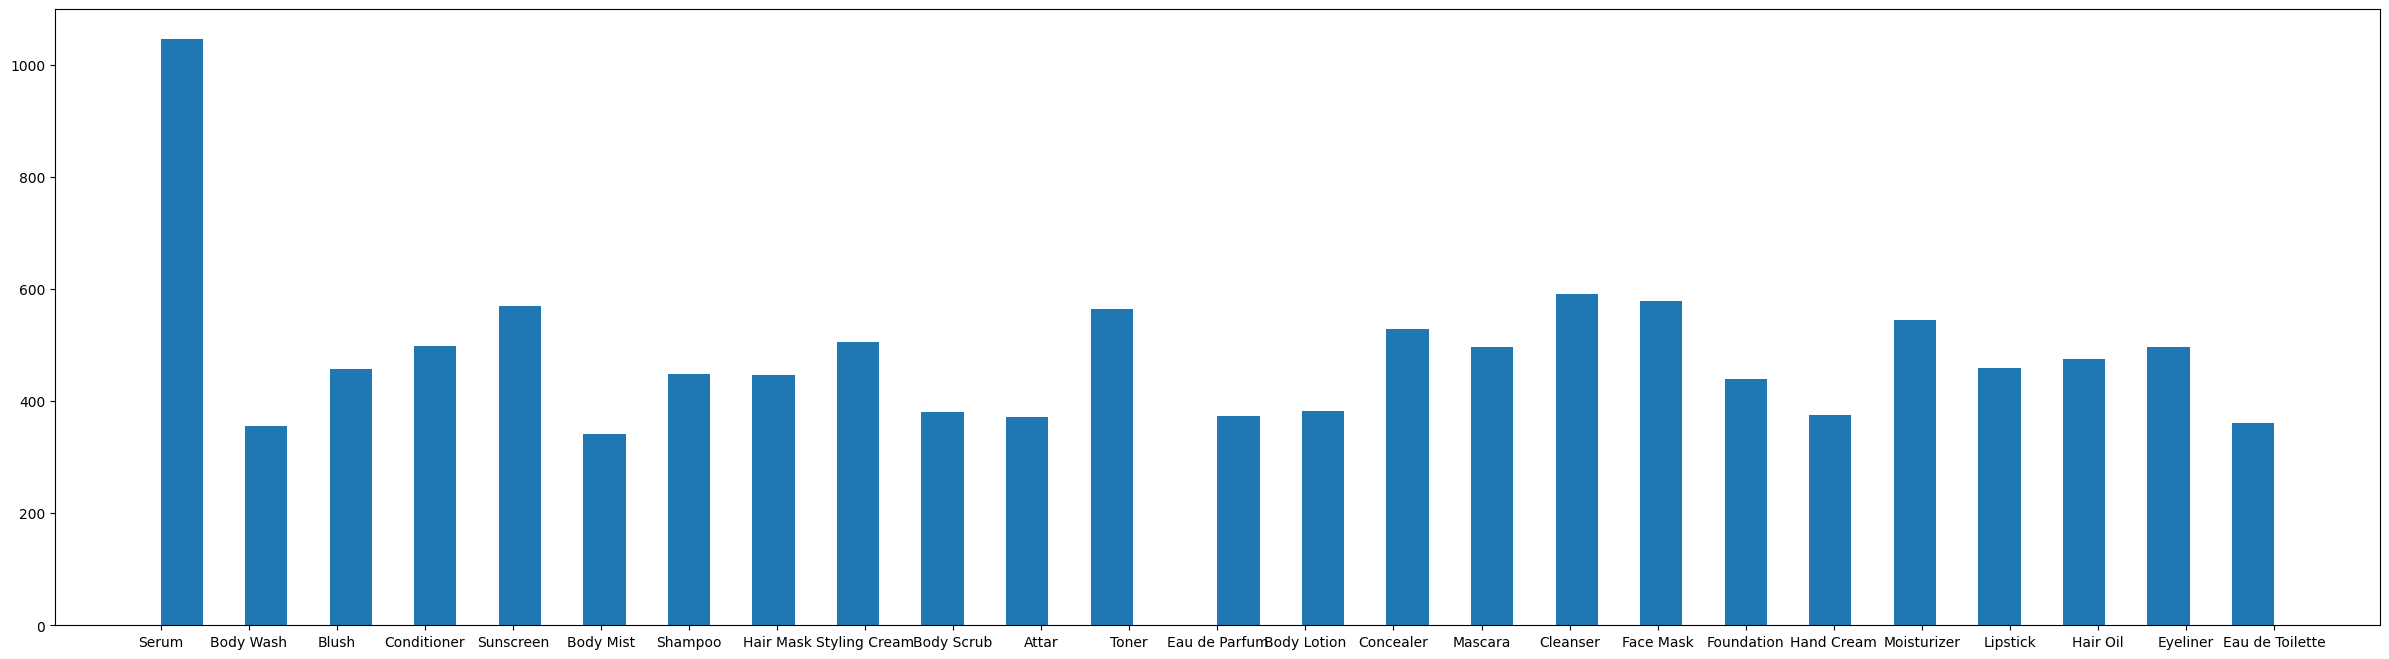

In [18]:
plt.figure(figsize=(30,8))
plt.hist(dt["subcategory"],bins=50)
plt.show()

<Axes: xlabel='primary_channel'>

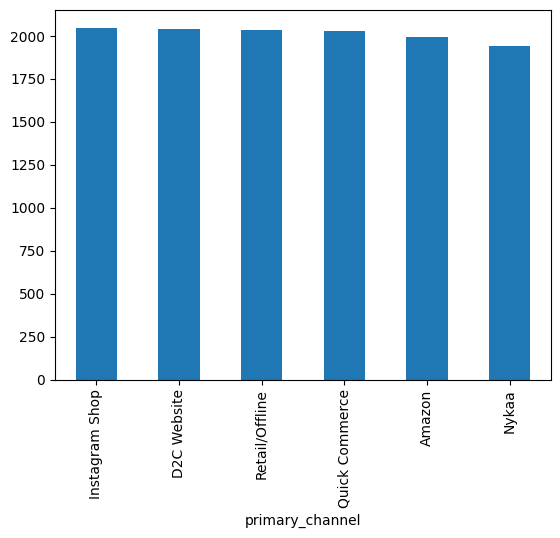

In [20]:
dt["primary_channel"].value_counts().plot(kind="bar")

<Axes: xlabel='brand'>

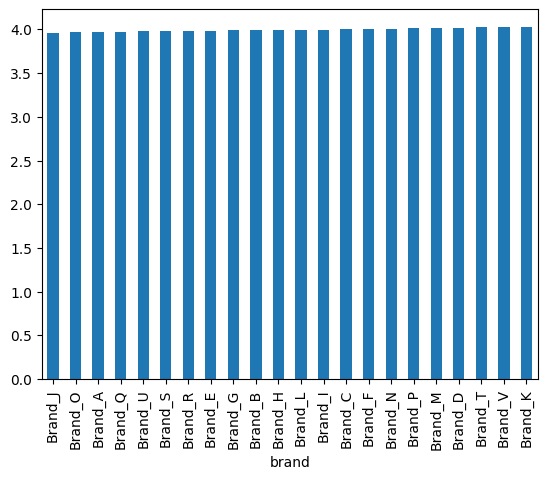

In [3]:
dt.groupby("brand")["avg_rating"].mean().sort_values().plot(kind="bar")

<Axes: xlabel='category', ylabel='price_inr'>

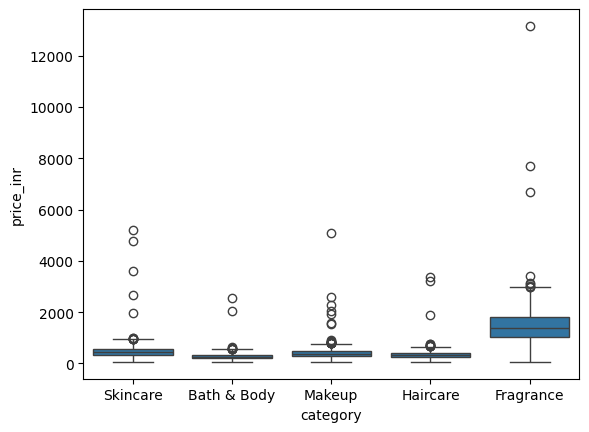

In [5]:
sns.boxplot(data=dt, x="category", y="price_inr")

<Axes: >

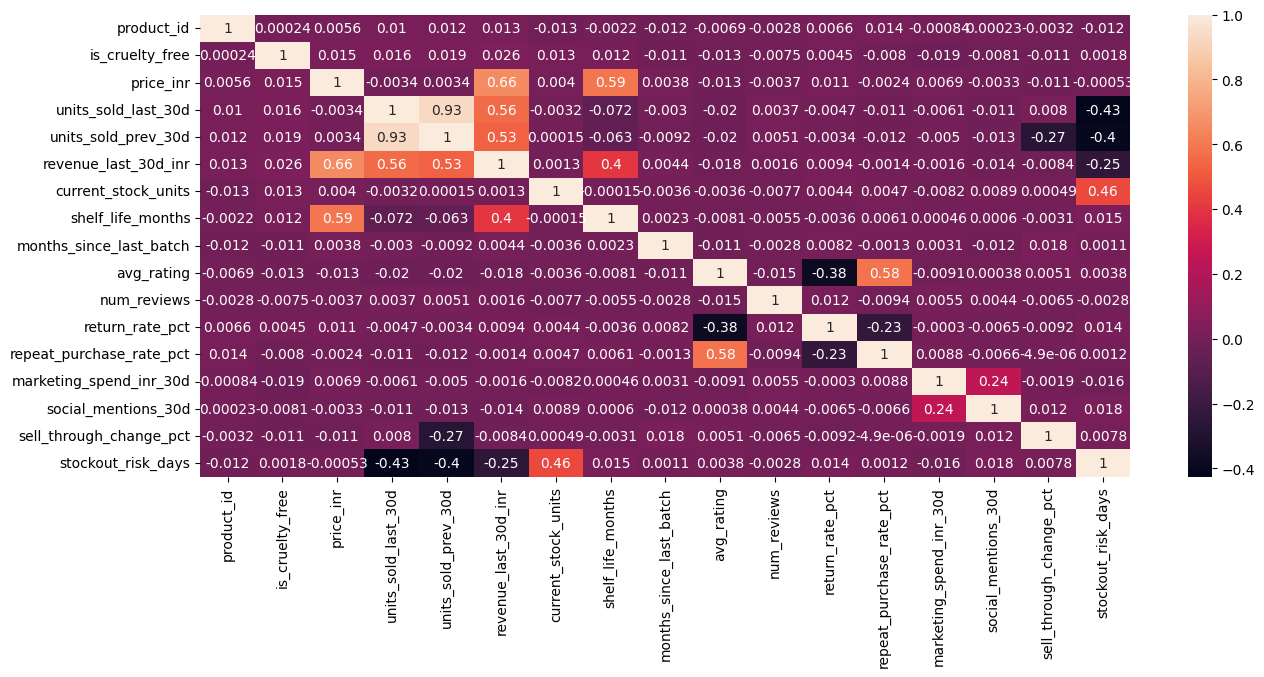

In [11]:
plt.figure(figsize=(15,6))
sns.heatmap(
    dt.corr(numeric_only=True),
    annot=True
)

<Axes: xlabel='price_inr', ylabel='Count'>

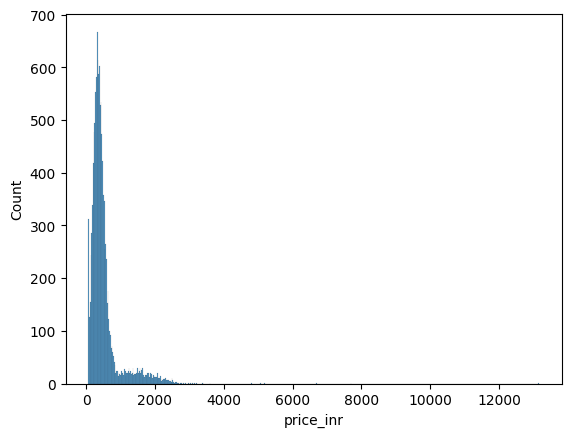

In [15]:
sns.histplot(dt["price_inr"])

<Axes: xlabel='target_type', ylabel='count'>

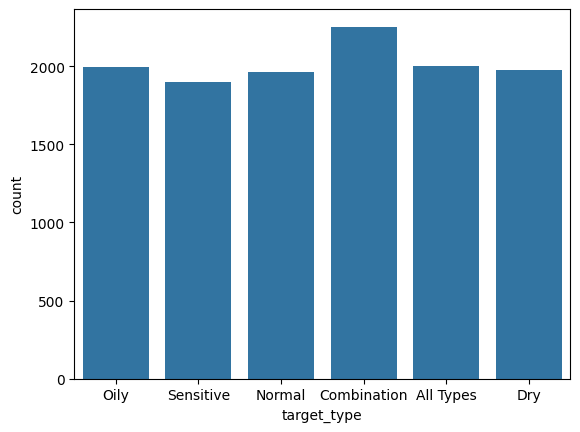

In [17]:
sns.countplot(data=dt, x="target_type")

<Axes: xlabel='price_inr', ylabel='avg_rating'>

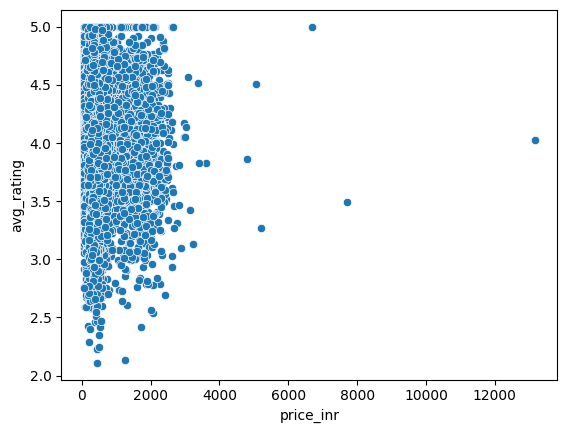

In [22]:
sns.scatterplot(data=dt, x="price_inr", y="avg_rating")

<Axes: xlabel='brand'>

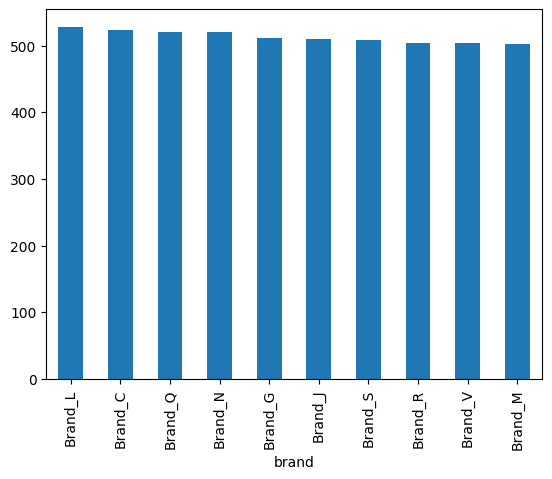

In [23]:
dt.groupby("brand")["price_inr"] \
.mean() \
.sort_values(ascending=False) \
.head(10) \
.plot(kind="bar")

<Axes: xlabel='ingredient_type'>

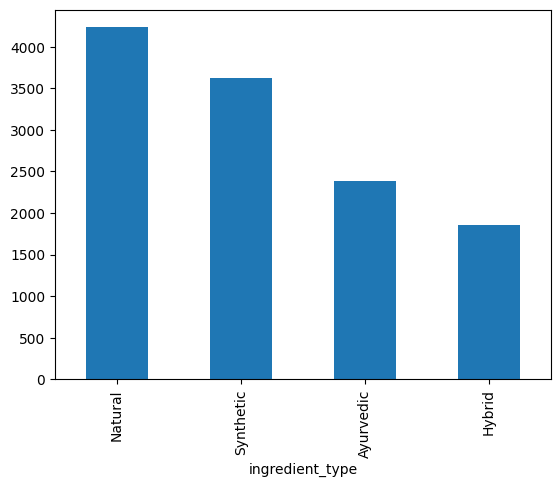

In [24]:
ingredients = (
    dt["ingredient_type"]
    .str.split(",")
    .explode()
    .str.strip()
)

ingredients.value_counts().head(10).plot(kind="bar")

## Next StepsThis analysis focused on descriptive patterns across channel, brand, product, and geography. Natural extensions include:- A repeat-purchase prediction model using rating, price, and channel as features- Marketing spend efficiency modeling to optimize budget allocation across brands- Cohort-based customer lifetime value analysis by acquisition channel